# FASE 5. DISEÑO CORRECTO DE LA VALIDACIÓN

In [ ]:
import pandas as pd
from pathlib import Path

# =============================================================================
# RUTA PARA GUARDAR LAS FIGURAS DE MODELADO BASELINE
# =============================================================================

BASELINE_FIGURES_PATH = Path("../figures/04_modelado")

BASELINE_FIGURES_PATH.mkdir(
    parents=True,
    exist_ok=True,
)

In [2]:
# -----------------------------------------------------------------------------
# 1. Carga del dataset preparado
# -----------------------------------------------------------------------------

PROJECT_ROOT = Path("..")
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed"

df_model = pd.read_parquet(
    PROCESSED_DATA_PATH / "train_prepared.parquet"
)

In [3]:
# Ordenamos el dataset cronológicamente.
df_model = (
    df_model
    .sort_values(["date", "store_nbr", "family"])
    .reset_index(drop=True)
)

In [4]:
# -----------------------------------------------------------------------------
# 2. Comprobación del rango temporal
# -----------------------------------------------------------------------------

min_date = df_model["date"].min()
max_date = df_model["date"].max()

print("Rango temporal completo")
print("-" * 50)
print(f"Fecha inicial: {min_date.date()}")
print(f"Fecha final:   {max_date.date()}")
print(f"Número de fechas: {df_model['date'].nunique()}")

Rango temporal completo
--------------------------------------------------
Fecha inicial: 2013-01-01
Fecha final:   2017-08-15
Número de fechas: 1684


In [ ]:
# -----------------------------------------------------------------------------
# 3. Definición de la duración de validación y test
# -----------------------------------------------------------------------------

VALIDATION_DAYS = 28
TEST_DAYS = 28

In [ ]:
# -----------------------------------------------------------------------------
# 4. Cálculo de las fechas de corte
# -----------------------------------------------------------------------------

test_end_date = max_date

test_start_date = (
    test_end_date
    - pd.Timedelta(days=TEST_DAYS - 1)
)

validation_end_date = (
    test_start_date
    - pd.Timedelta(days=1)
)

validation_start_date = (
    validation_end_date
    - pd.Timedelta(days=VALIDATION_DAYS - 1)
)

train_end_date = (
    validation_start_date
    - pd.Timedelta(days=1)
)

In [7]:
# -----------------------------------------------------------------------------
# 5. Creación de las particiones temporales
# -----------------------------------------------------------------------------

train_df = df_model[
    df_model["date"] <= train_end_date
].copy()

validation_df = df_model[
    (df_model["date"] >= validation_start_date)
    & (df_model["date"] <= validation_end_date)
].copy()

test_df = df_model[
    (df_model["date"] >= test_start_date)
    & (df_model["date"] <= test_end_date)
].copy()

In [8]:
# -----------------------------------------------------------------------------
# 6. Resumen de la división
# -----------------------------------------------------------------------------

split_summary = pd.DataFrame(
    {
        "partition": [
            "Entrenamiento",
            "Validación",
            "Test interno",
        ],
        "start_date": [
            train_df["date"].min(),
            validation_df["date"].min(),
            test_df["date"].min(),
        ],
        "end_date": [
            train_df["date"].max(),
            validation_df["date"].max(),
            test_df["date"].max(),
        ],
        "rows": [
            len(train_df),
            len(validation_df),
            len(test_df),
        ],
        "dates": [
            train_df["date"].nunique(),
            validation_df["date"].nunique(),
            test_df["date"].nunique(),
        ],
        "stores": [
            train_df["store_nbr"].nunique(),
            validation_df["store_nbr"].nunique(),
            test_df["store_nbr"].nunique(),
        ],
        "families": [
            train_df["family"].nunique(),
            validation_df["family"].nunique(),
            test_df["family"].nunique(),
        ],
    }
)

display(split_summary)

,partition,start_date,end_date,rows,dates,stores,families
0,Entrenamiento,2013-01-01,2017-06-20,2901096,1628,54,33
1,Validación,2017-06-21,2017-07-18,49896,28,54,33
2,Test interno,2017-07-19,2017-08-15,49896,28,54,33


In [ ]:
# -----------------------------------------------------------------------------
# 7. Comprobaciones de coherencia temporal
# -----------------------------------------------------------------------------

assert train_df["date"].max() < validation_df["date"].min(), (
    "El entrenamiento y la validación se solapan."
)

assert validation_df["date"].max() < test_df["date"].min(), (
    "La validación y el test se solapan."
)

train_dates = set(train_df["date"].unique())
validation_dates = set(validation_df["date"].unique())
test_dates = set(test_df["date"].unique())

assert train_dates.isdisjoint(validation_dates), (
    "Hay fechas compartidas entre entrenamiento y validación."
)

assert train_dates.isdisjoint(test_dates), (
    "Hay fechas compartidas entre entrenamiento y test."
)

assert validation_dates.isdisjoint(test_dates), (
    "Hay fechas compartidas entre validación y test."
)

total_rows = (
    len(train_df)
    + len(validation_df)
    + len(test_df)
)

assert total_rows == len(df_model), (
    "La suma de las particiones no coincide con el dataset original."
)


print("\nLa división temporal se ha realizado correctamente.")
print(
    f"\nEntrenamiento: "
    f"{train_df['date'].min().date()} - "
    f"{train_df['date'].max().date()}"
)

print(
    f"Validación: "
    f"{validation_df['date'].min().date()} - "
    f"{validation_df['date'].max().date()}"
)

print(
    f"Test interno: "
    f"{test_df['date'].min().date()} - "
    f"{test_df['date'].max().date()}"
)


La división temporal se ha realizado correctamente.

Entrenamiento: 2013-01-01 - 2017-06-20
Validación: 2017-06-21 - 2017-07-18
Test interno: 2017-07-19 - 2017-08-15


In [ ]:
# -----------------------------------------------------------------------------
# 8. Guardado de las fechas de corte
# -----------------------------------------------------------------------------

split_dates = pd.DataFrame(
    {
        "partition": [
            "train",
            "validation",
            "test",
        ],
        "start_date": [
            train_df["date"].min(),
            validation_df["date"].min(),
            test_df["date"].min(),
        ],
        "end_date": [
            train_df["date"].max(),
            validation_df["date"].max(),
            test_df["date"].max(),
        ],
    }
)

split_dates_path = (
    PROCESSED_DATA_PATH
    / "temporal_split_dates.csv"
)

split_dates.to_csv(
    split_dates_path,
    index=False
)

print(
    f"\nFechas de división guardadas en:\n"
    f"{split_dates_path}"
)


Fechas de división guardadas en:
../data/processed/temporal_split_dates.csv


# FASE 6. MODELADO PREDICTIVO — Baseline y series temporales clásicas

In [11]:
%pip install statsmodels


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [12]:
# =============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# =============================================================================

import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_log_error,
    root_mean_squared_error,
)

warnings.filterwarnings("ignore")


# Modelos clásicos de series temporales
from statsmodels.tsa.holtwinters import (
    SimpleExpSmoothing,
    ExponentialSmoothing,
)

from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
# =============================================================================
# 2. DEFINICIÓN DE RUTAS Y CARGA DE DATOS
# =============================================================================

PROJECT_ROOT = Path("..")

PROCESSED_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

RESULTS_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "results"
)

RESULTS_DATA_PATH.mkdir(
    parents=True,
    exist_ok=True
)


df_model = pd.read_parquet(
    PROCESSED_DATA_PATH
    / "train_prepared.parquet"
)


# Fechas de la división temporal
split_dates = pd.read_csv(
    PROCESSED_DATA_PATH
    / "temporal_split_dates.csv",
    parse_dates=["start_date", "end_date"],
)


# Orden cronológico
df_model = (
    df_model
    .sort_values(
        ["store_nbr", "family", "date"]
    )
    .reset_index(drop=True)
)


print("Dimensiones:", df_model.shape)

print(
    "Periodo:",
    df_model["date"].min().date(),
    "-",
    df_model["date"].max().date(),
)

display(split_dates)

Dimensiones: (3000888, 53)
Periodo: 2013-01-01 - 2017-08-15


,partition,start_date,end_date
0,train,2013-01-01,2017-06-20
1,validation,2017-06-21,2017-07-18
2,test,2017-07-19,2017-08-15


In [14]:
# =============================================================================
# 3. RECUPERACIÓN DE LAS FECHAS DE DIVISIÓN
# =============================================================================

train_start = split_dates.loc[
    split_dates["partition"] == "train",
    "start_date",
].iloc[0]

train_end = split_dates.loc[
    split_dates["partition"] == "train",
    "end_date",
].iloc[0]

validation_start = split_dates.loc[
    split_dates["partition"] == "validation",
    "start_date",
].iloc[0]

validation_end = split_dates.loc[
    split_dates["partition"] == "validation",
    "end_date",
].iloc[0]

test_start = split_dates.loc[
    split_dates["partition"] == "test",
    "start_date",
].iloc[0]

test_end = split_dates.loc[
    split_dates["partition"] == "test",
    "end_date",
].iloc[0]


print(
    f"Entrenamiento: {train_start.date()} - "
    f"{train_end.date()}"
)

print(
    f"Validación: {validation_start.date()} - "
    f"{validation_end.date()}"
)

print(
    f"Test interno: {test_start.date()} - "
    f"{test_end.date()}"
)

Entrenamiento: 2013-01-01 - 2017-06-20
Validación: 2017-06-21 - 2017-07-18
Test interno: 2017-07-19 - 2017-08-15


In [15]:
# =============================================================================
# 4. CREACIÓN DE LAS PARTICIONES
# =============================================================================

train_df = df_model[
    (df_model["date"] >= train_start)
    & (df_model["date"] <= train_end)
].copy()

validation_df = df_model[
    (df_model["date"] >= validation_start)
    & (df_model["date"] <= validation_end)
].copy()

test_df = df_model[
    (df_model["date"] >= test_start)
    & (df_model["date"] <= test_end)
].copy()


print("Entrenamiento:", train_df.shape)
print("Validación:", validation_df.shape)
print("Test interno:", test_df.shape)

Entrenamiento: (2901096, 53)
Validación: (49896, 53)
Test interno: (49896, 53)


In [ ]:
# =============================================================================
# 5. FUNCIONES DE EVALUACIÓN
# =============================================================================

def calculate_metrics(
    y_true,
    y_pred,
):
    """
    Calcula las métricas de evaluación.

    Las predicciones negativas se sustituyen por cero porque las ventas
    no pueden ser negativas.
    """

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)


    y_pred = np.clip(
        y_pred,
        a_min=0,
        a_max=None,
    )

    return {
        "RMSLE": np.sqrt(
            mean_squared_log_error(
                y_true,
                y_pred,
            )
        ),
        "MAE": mean_absolute_error(
            y_true,
            y_pred,
        ),
        "RMSE": root_mean_squared_error(
            y_true,
            y_pred,
        ),
    }

In [17]:
def evaluate_prediction_column(
    df,
    prediction_column,
    model_name,
):
    """
    Evalúa una columna de predicciones.

    Las filas sin predicción se excluyen de la evaluación.
    """

    evaluation_df = df[
        ["sales", prediction_column]
    ].dropna()

    metrics = calculate_metrics(
        evaluation_df["sales"],
        evaluation_df[prediction_column],
    )

    metrics["model"] = model_name
    metrics["observations"] = len(
        evaluation_df
    )

    return metrics

In [ ]:
# =============================================================================
# 6.1. MODELOS BASELINE
# =============================================================================

baseline_df = (
    df_model
    .sort_values(
        ["store_nbr", "family", "date"]
    )
    .copy()
)


series_keys = [
    "store_nbr",
    "family",
]


# -----------------------------------------------------------------------------
# Baseline 1: última observación
# -----------------------------------------------------------------------------

baseline_df["prediction_last_observation"] = (
    baseline_df
    .groupby(
        series_keys,
        observed=True,
    )["sales"]
    .shift(1)
)


# -----------------------------------------------------------------------------
# Baseline 2: valor de la semana anterior
# -----------------------------------------------------------------------------

baseline_df["prediction_lag_7"] = (
    baseline_df
    .groupby(
        series_keys,
        observed=True,
    )["sales"]
    .shift(7)
)


# -----------------------------------------------------------------------------
# Baseline 3: media móvil de 7 días
# -----------------------------------------------------------------------------

baseline_df["prediction_rolling_mean_7"] = (
    baseline_df
    .groupby(
        series_keys,
        observed=True,
    )["sales"]
    .transform(
        lambda series: (
            series
            .shift(1)
            .rolling(
                window=7,
                min_periods=1,
            )
            .mean()
        )
    )
)


# -----------------------------------------------------------------------------
# Baseline 4: media móvil de 14 días
# -----------------------------------------------------------------------------

baseline_df["prediction_rolling_mean_14"] = (
    baseline_df
    .groupby(
        series_keys,
        observed=True,
    )["sales"]
    .transform(
        lambda series: (
            series
            .shift(1)
            .rolling(
                window=14,
                min_periods=1,
            )
            .mean()
        )
    )
)


# -----------------------------------------------------------------------------
# Baseline 5: media móvil de 28 días
# -----------------------------------------------------------------------------

baseline_df["prediction_rolling_mean_28"] = (
    baseline_df
    .groupby(
        series_keys,
        observed=True,
    )["sales"]
    .transform(
        lambda series: (
            series
            .shift(1)
            .rolling(
                window=28,
                min_periods=1,
            )
            .mean()
        )
    )
)


# -----------------------------------------------------------------------------
# Baseline 6: promedio histórico por tienda y familia
# -----------------------------------------------------------------------------

baseline_df["prediction_store_family_mean"] = (
    baseline_df
    .groupby(
        series_keys,
        observed=True,
    )["sales"]
    .transform(
        lambda series: (
            series
            .shift(1)
            .expanding(
                min_periods=1
            )
            .mean()
        )
    )
)

In [ ]:
# =============================================================================
# VALOR EXACTO DE HACE SIETE DÍAS
# =============================================================================

lag_7_exact = df_model[
    [
        "date",
        "store_nbr",
        "family",
        "sales",
    ]
].copy()

lag_7_exact["date"] = (
    lag_7_exact["date"]
    + pd.Timedelta(days=7)
)


lag_7_exact = lag_7_exact.rename(
    columns={
        "sales": "prediction_lag_7_exact"
    }
)


baseline_df = baseline_df.merge(
    lag_7_exact,
    on=[
        "date",
        "store_nbr",
        "family",
    ],
    how="left",
    validate="one_to_one",
)

In [ ]:
baseline_validation = baseline_df[
    (
        baseline_df["date"]
        >= validation_start
    )
    & (
        baseline_df["date"]
        <= validation_end
    )
].copy()


print(
    "Filas de validación:",
    len(baseline_validation),
)

Filas de validación: 49896


In [21]:
# =============================================================================
# EVALUACIÓN DE LOS BASELINES
# =============================================================================

baseline_models = {
    "Última observación":
        "prediction_last_observation",

    "Semana anterior":
        "prediction_lag_7_exact",

    "Media móvil 7 días":
        "prediction_rolling_mean_7",

    "Media móvil 14 días":
        "prediction_rolling_mean_14",

    "Media móvil 28 días":
        "prediction_rolling_mean_28",

    "Media histórica tienda-familia":
        "prediction_store_family_mean",
}


baseline_results = []

for model_name, prediction_column in baseline_models.items():

    result = evaluate_prediction_column(
        df=baseline_validation,
        prediction_column=prediction_column,
        model_name=model_name,
    )

    baseline_results.append(result)


baseline_results_df = pd.DataFrame(
    baseline_results
)


baseline_results_df = baseline_results_df[
    [
        "model",
        "RMSLE",
        "MAE",
        "RMSE",
        "observations",
    ]
].sort_values(
    "RMSLE"
).reset_index(drop=True)


display(baseline_results_df)

,model,RMSLE,MAE,RMSE,observations
0,Media móvil 14 días,0.455991,113.706023,416.172273,49896
1,Media móvil 28 días,0.456089,115.696652,415.812185,49896
2,Media móvil 7 días,0.459232,113.490885,416.715694,49896
3,Semana anterior,0.514183,83.290993,327.513184,49896
4,Última observación,0.553392,130.450516,479.479523,49896
5,Media histórica tienda-familia,0.667532,158.286049,595.360016,49896


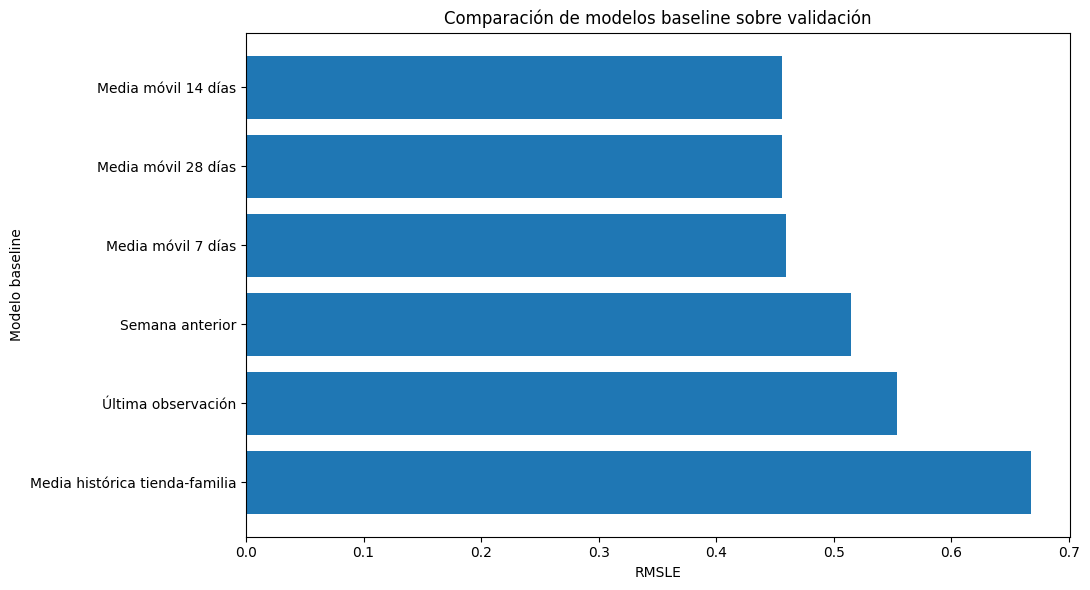

In [22]:
plt.figure(figsize=(11, 6))

plt.barh(
    baseline_results_df["model"],
    baseline_results_df["RMSLE"],
)

plt.xlabel("RMSLE")
plt.ylabel("Modelo baseline")
plt.title(
    "Comparación de modelos baseline "
    "sobre validación"
)

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    BASELINE_FIGURES_PATH / "comparacion_baselines.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

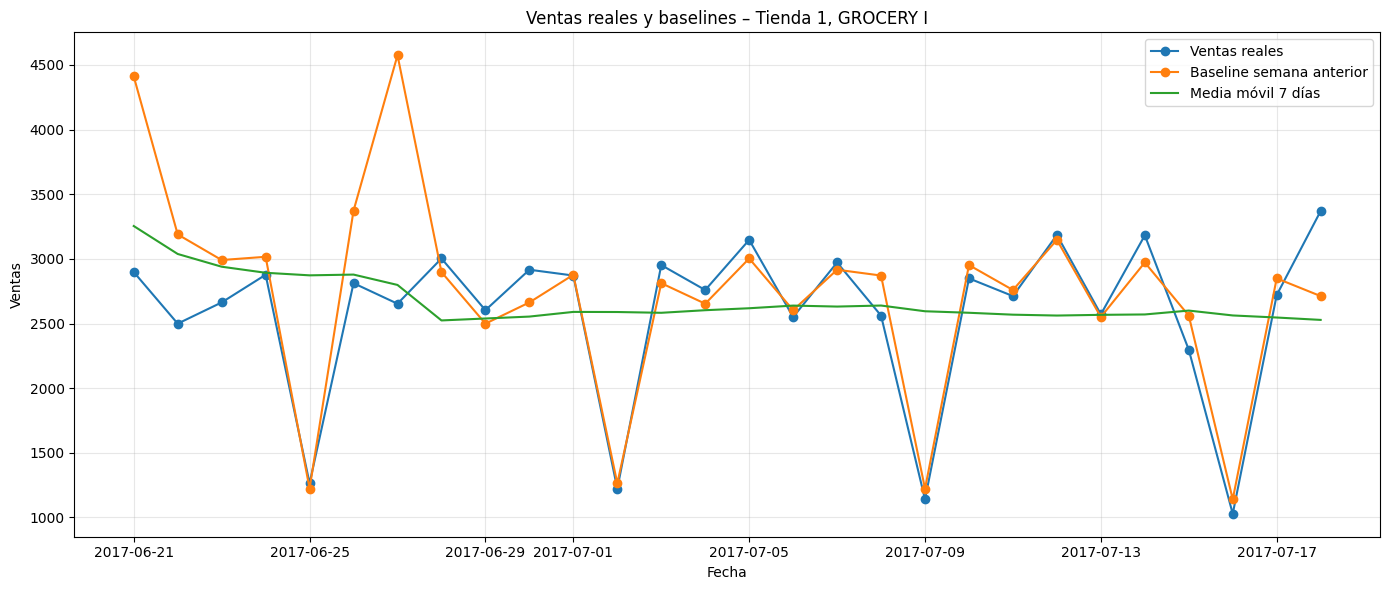

In [ ]:
example_store = 1
example_family = "GROCERY I"


example_series = baseline_validation[
    (
        baseline_validation["store_nbr"]
        == example_store
    )
    & (
        baseline_validation["family"]
        == example_family
    )
].copy()


plt.figure(figsize=(14, 6))

plt.plot(
    example_series["date"],
    example_series["sales"],
    marker="o",
    label="Ventas reales",
)

plt.plot(
    example_series["date"],
    example_series[
        "prediction_lag_7_exact"
    ],
    marker="o",
    label="Baseline semana anterior",
)

plt.plot(
    example_series["date"],
    example_series[
        "prediction_rolling_mean_7"
    ],
    label="Media móvil 7 días",
)

plt.title(
    f"Ventas reales y baselines – "
    f"Tienda {example_store}, "
    f"{example_family}"
)

plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    BASELINE_FIGURES_PATH / "serie_real_vs_baselines.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [ ]:
# =============================================================================
# 6.2. SERIE TEMPORAL AGREGADA
# =============================================================================

daily_sales = (
    df_model
    .groupby("date")["sales"]
    .sum()
    .sort_index()
    .astype("float64")
)

full_date_range = pd.date_range(
    start=daily_sales.index.min(),
    end=daily_sales.index.max(),
    freq="D",
)


daily_sales = daily_sales.reindex(
    full_date_range
)

daily_sales.index.name = "date"


print(
    "Fechas ausentes en la serie agregada:",
    daily_sales.isna().sum(),
)

Fechas ausentes en la serie agregada: 4


In [ ]:
daily_sales_regular = (
    daily_sales
    .interpolate(
        method="time"
    )
    .ffill()
    .bfill()
)


daily_sales_regular.isna().sum()

0

In [26]:
aggregate_train = daily_sales_regular.loc[
    train_start:train_end
].copy()

aggregate_validation = daily_sales_regular.loc[
    validation_start:validation_end
].copy()


print(
    "Entrenamiento agregado:",
    aggregate_train.index.min().date(),
    "-",
    aggregate_train.index.max().date(),
)

print(
    "Validación agregada:",
    aggregate_validation.index.min().date(),
    "-",
    aggregate_validation.index.max().date(),
)

print(
    "Días de validación:",
    len(aggregate_validation),
)

Entrenamiento agregado: 2013-01-01 - 2017-06-20
Validación agregada: 2017-06-21 - 2017-07-18
Días de validación: 28


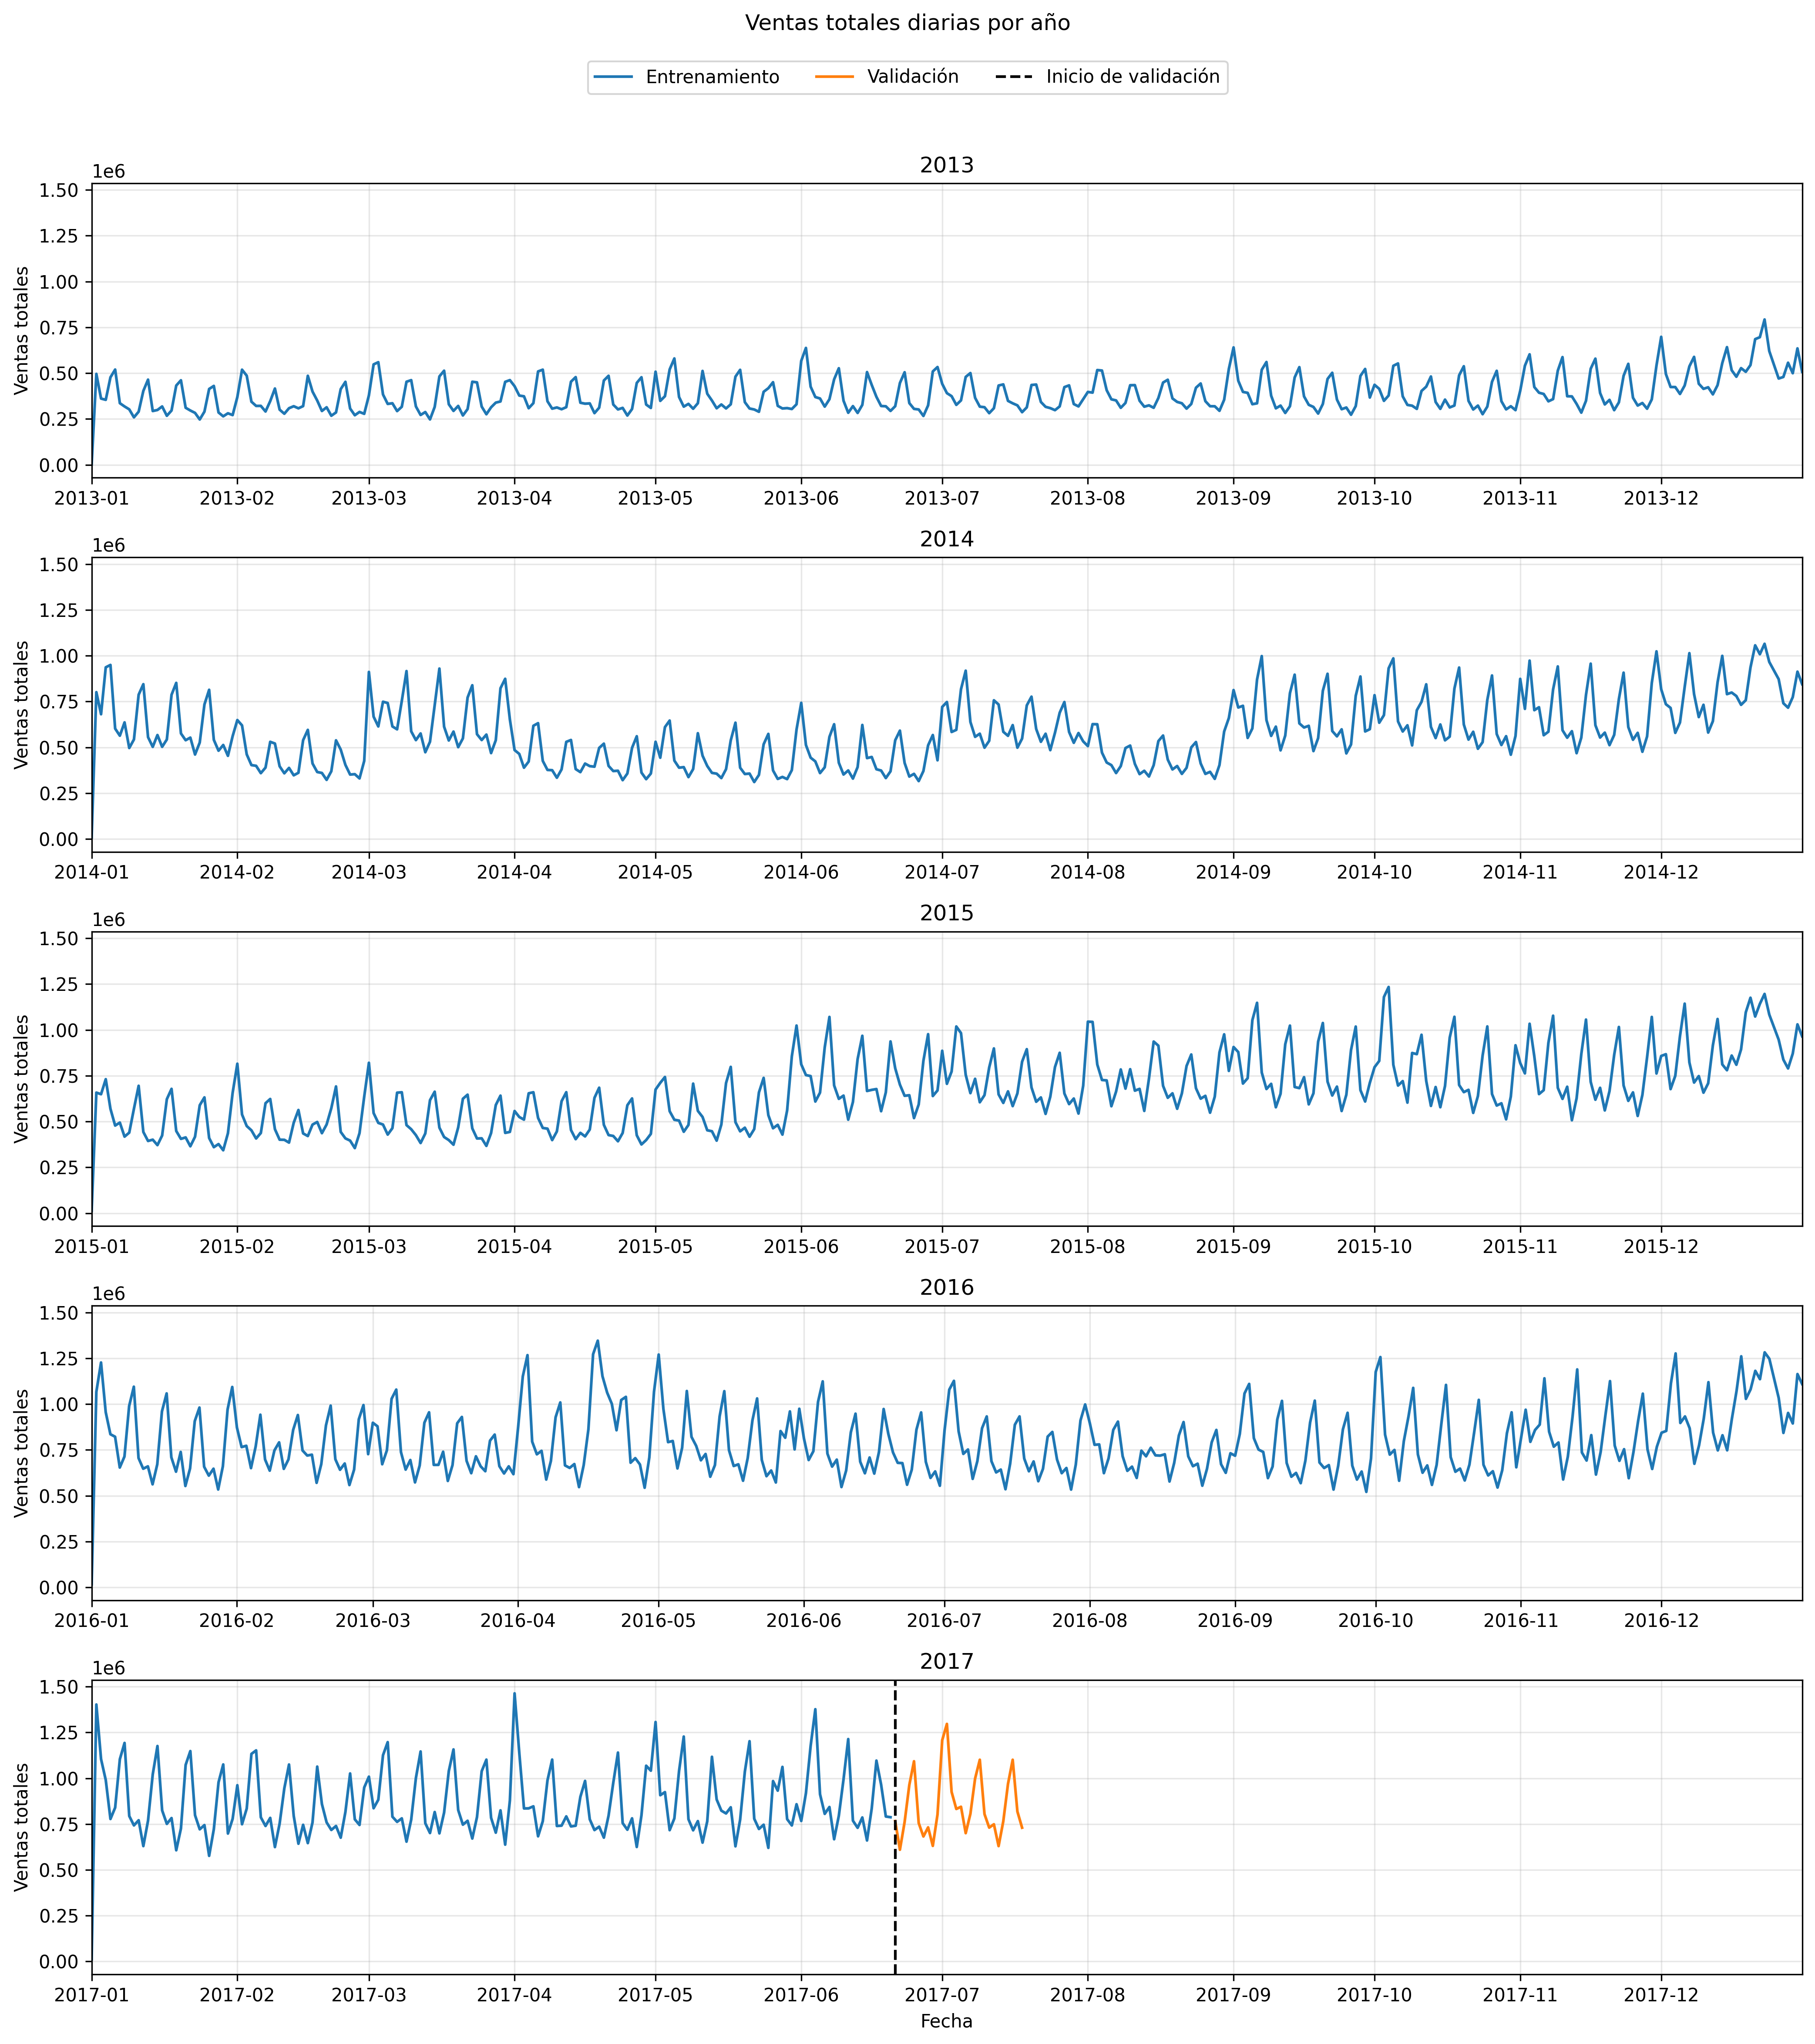

In [ ]:
years = sorted(daily_sales_regular.index.year.unique())

fig, axes = plt.subplots(
    len(years), 1,
    figsize=(14, 3 * len(years)),
    sharey=True,
)

for ax, year in zip(axes, years):
    year_start = pd.Timestamp(f"{year}-01-01")
    year_end = pd.Timestamp(f"{year}-12-31")

    train_slice = aggregate_train.loc[year_start:year_end]
    val_slice = aggregate_validation.loc[year_start:year_end]

    if len(train_slice):
        ax.plot(
            train_slice.index,
            train_slice.values,
            label="Entrenamiento",
            color="tab:blue",
        )

    if len(val_slice):
        ax.plot(
            val_slice.index,
            val_slice.values,
            label="Validación",
            color="tab:orange",
        )
        ax.axvline(
            validation_start,
            linestyle="--",
            color="black",
            label="Inicio de validación",
        )

    ax.set_title(str(year))
    ax.set_ylabel("Ventas totales")
    ax.grid(alpha=0.3)
    ax.set_xlim(year_start, year_end)

axes[-1].set_xlabel("Fecha")

handles, labels = axes[-1].get_legend_handles_labels()
if not handles:
    handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(
    by_label.values(),
    by_label.keys(),
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.02),
)

fig.suptitle("Ventas totales diarias por año", y=1.04)
fig.tight_layout()

fig.savefig(
    BASELINE_FIGURES_PATH / "train_validacion_temporal.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [28]:
# =============================================================================
# MODELO CLÁSICO 1: MEDIA MÓVIL
# =============================================================================

moving_average_window = 28

moving_average_value = (
    aggregate_train
    .tail(moving_average_window)
    .mean()
)


moving_average_forecast = pd.Series(
    data=moving_average_value,
    index=aggregate_validation.index,
    name="Moving average 28",
)


print(
    "Predicción constante:",
    moving_average_value,
)

Predicción constante: 878912.7924107143


In [29]:
# =============================================================================
# MODELO CLÁSICO 2: SUAVIZADO EXPONENCIAL SIMPLE
# =============================================================================

start_time = time.time()


simple_exp_model = SimpleExpSmoothing(
    aggregate_train,
    initialization_method="estimated",
)


simple_exp_fitted = simple_exp_model.fit(
    optimized=True
)


simple_exp_forecast = simple_exp_fitted.forecast(
    steps=len(aggregate_validation)
)


simple_exp_time = (
    time.time() - start_time
)


simple_exp_forecast.index = (
    aggregate_validation.index
)

In [ ]:
# =============================================================================
# MODELO CLÁSICO 3: HOLT-WINTERS
# =============================================================================
start_time = time.time()


holt_winters_model = ExponentialSmoothing(
    aggregate_train,
    trend="add",
    damped_trend=True,
    seasonal="add",
    seasonal_periods=7,
    initialization_method="estimated",
)


holt_winters_fitted = (
    holt_winters_model.fit(
        optimized=True
    )
)


holt_winters_forecast = (
    holt_winters_fitted.forecast(
        steps=len(aggregate_validation)
    )
)


holt_winters_time = (
    time.time() - start_time
)


holt_winters_forecast.index = (
    aggregate_validation.index
)

holt_winters_forecast = (
    holt_winters_forecast.clip(lower=0)
)

In [ ]:
# =============================================================================
# MODELO CLÁSICO 4: SARIMA
# =============================================================================

start_time = time.time()


aggregate_train_log = np.log1p(
    aggregate_train
)


sarima_model = SARIMAX(
    aggregate_train_log,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
)


sarima_fitted = sarima_model.fit(
    disp=False,
    maxiter=200,
)


sarima_forecast_log = (
    sarima_fitted.forecast(
        steps=len(aggregate_validation)
    )
)

sarima_forecast = np.expm1(
    sarima_forecast_log
)


sarima_forecast = pd.Series(
    data=np.clip(
        sarima_forecast,
        a_min=0,
        a_max=None,
    ),
    index=aggregate_validation.index,
    name="SARIMA",
)


sarima_time = (
    time.time() - start_time
)

In [32]:
# =============================================================================
# EVALUACIÓN DE LOS MODELOS CLÁSICOS
# =============================================================================

classical_forecasts = {
    "Media móvil 28 días":
        moving_average_forecast,

    "Suavizado exponencial simple":
        simple_exp_forecast,

    "Holt-Winters semanal":
        holt_winters_forecast,

    "SARIMA semanal":
        sarima_forecast,
}


classical_results = []


for model_name, forecast in classical_forecasts.items():

    metrics = calculate_metrics(
        aggregate_validation.values,
        forecast.values,
    )

    metrics["model"] = model_name
    metrics["observations"] = len(
        aggregate_validation
    )

    classical_results.append(metrics)


classical_results_df = pd.DataFrame(
    classical_results
)


classical_results_df = classical_results_df[
    [
        "model",
        "RMSLE",
        "MAE",
        "RMSE",
        "observations",
    ]
].sort_values(
    "RMSLE"
).reset_index(drop=True)


display(classical_results_df)

,model,RMSLE,MAE,RMSE,observations
0,Holt-Winters semanal,0.077646,53725.029626,73667.321879,28
1,SARIMA semanal,0.080697,58291.385459,73433.808941,28
2,Suavizado exponencial simple,0.199328,148655.592666,176237.260671,28
3,Media móvil 28 días,0.202740,153344.865593,177885.302667,28


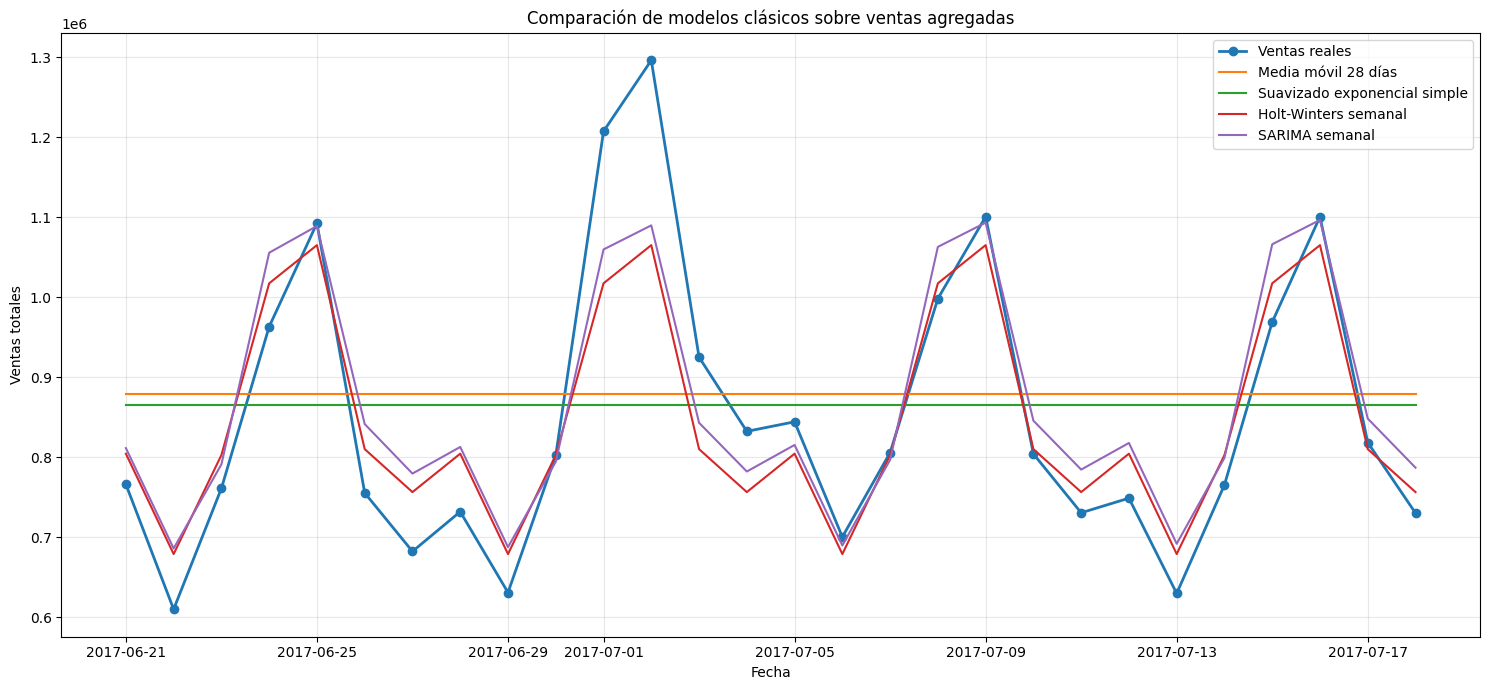

In [33]:
plt.figure(figsize=(15, 7))

plt.plot(
    aggregate_validation.index,
    aggregate_validation.values,
    marker="o",
    linewidth=2,
    label="Ventas reales",
)


for model_name, forecast in classical_forecasts.items():

    plt.plot(
        forecast.index,
        forecast.values,
        label=model_name,
    )


plt.title(
    "Comparación de modelos clásicos "
    "sobre ventas agregadas"
)

plt.xlabel("Fecha")
plt.ylabel("Ventas totales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    BASELINE_FIGURES_PATH / "predicciones_modelos_clasicos.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

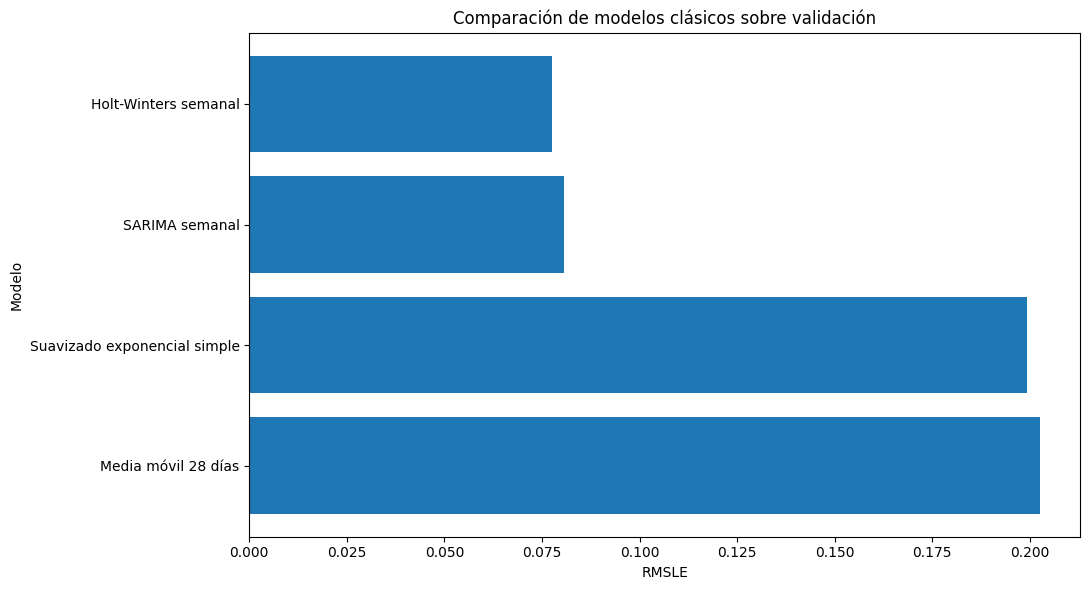

In [34]:
plt.figure(figsize=(11, 6))

plt.barh(
    classical_results_df["model"],
    classical_results_df["RMSLE"],
)

plt.xlabel("RMSLE")
plt.ylabel("Modelo")
plt.title(
    "Comparación de modelos clásicos "
    "sobre validación"
)

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    BASELINE_FIGURES_PATH / "comparacion_modelos_clasicos.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [35]:
# =============================================================================
# GUARDADO DE RESULTADOS
# =============================================================================

baseline_results_path = (
    RESULTS_DATA_PATH
    / "baseline_validation_results.csv"
)

classical_results_path = (
    RESULTS_DATA_PATH
    / "classical_time_series_results.csv"
)


baseline_results_df.to_csv(
    baseline_results_path,
    index=False,
)

classical_results_df.to_csv(
    classical_results_path,
    index=False,
)


print(
    "Resultados baseline guardados en:"
)

print(baseline_results_path)


print(
    "\nResultados de series clásicas guardados en:"
)

print(classical_results_path)

Resultados baseline guardados en:
../data/results/baseline_validation_results.csv

Resultados de series clásicas guardados en:
../data/results/classical_time_series_results.csv


In [36]:
baseline_prediction_columns = [
    "date",
    "store_nbr",
    "family",
    "sales",
    "prediction_last_observation",
    "prediction_lag_7_exact",
    "prediction_rolling_mean_7",
    "prediction_rolling_mean_14",
    "prediction_rolling_mean_28",
    "prediction_store_family_mean",
]


baseline_validation[
    baseline_prediction_columns
].to_parquet(
    RESULTS_DATA_PATH
    / "baseline_validation_predictions.parquet",
    index=False,
)

In [37]:
classical_predictions_df = pd.DataFrame(
    {
        "date":
            aggregate_validation.index,

        "actual_sales":
            aggregate_validation.values,

        "moving_average_28":
            moving_average_forecast.values,

        "simple_exponential_smoothing":
            simple_exp_forecast.values,

        "holt_winters":
            holt_winters_forecast.values,

        "sarima":
            sarima_forecast.values,
    }
)


classical_predictions_df.to_csv(
    RESULTS_DATA_PATH
    / "classical_time_series_predictions.csv",
    index=False,
)